In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [5]:
data = loadmat('cluster_dataset.mat')

In [6]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

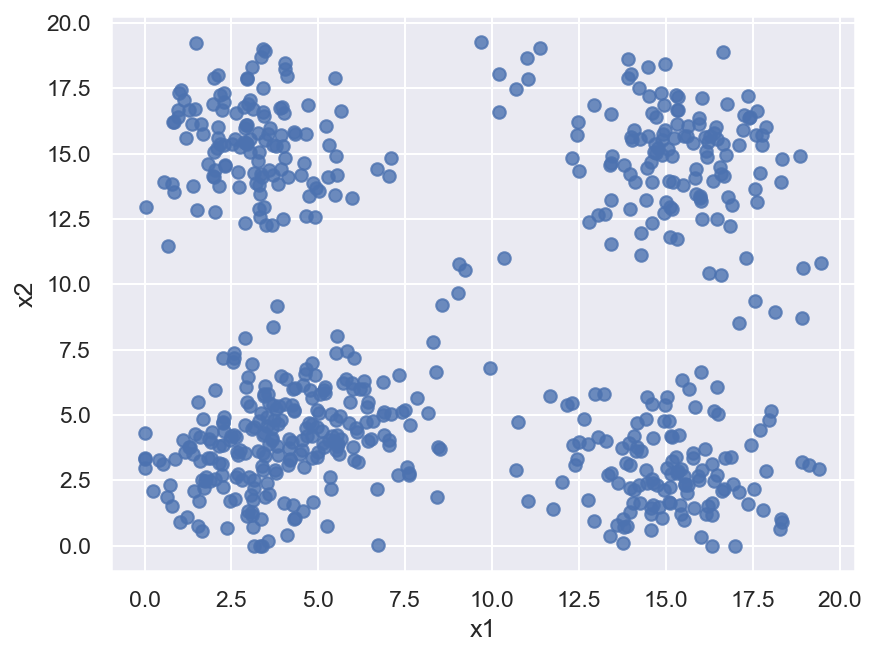

In [7]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [8]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [9]:
# 随机选择数据集中的 k 个样本作为初始聚类中心。
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k:预设的聚类簇数(int)
    输出：centers:初始化后的中心集（建议：元素为 ndarray 的 list）
    可能使用的函数：random.randint
    注意：需要保证随机取样不重复
    """
    # 直接从样本中抽取中心，保证初始中心来自数据集本身。
    # random.sample 会从下标集合中不重复地抽取 k 个索引。
    sample_idx = random.sample(range(len(X)), k)
    centers = [np.array(X[idx], dtype=float) for idx in sample_idx]
    return centers

In [10]:
# 向量欧氏距离计算，用于计算样本和中心的距离。
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    # 先统一转成 ndarray，兼容 list 和 ndarray 两类输入。
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    # 欧氏距离公式：sqrt(sum((v1 - v2)^2))。
    distance = np.linalg.norm(v1 - v2, axis=-1)
    return distance

In [11]:
# 将每个样本分配到距离最近的中心所在的簇。
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers:当前中心集（建议：元素为 ndarray 的 list）
    输出：assignment（建议：字典，key 为簇标号，value 为元素是 ndarray 的 list）
    可能使用的函数：np.argmin
    注意：list 和 array 在某些计算时需要转换
    """
    # 为每个簇准备一个列表，后面逐个追加属于该簇的样本。
    assignment = {i: [] for i in range(len(centers))}
    # 逐个样本计算它到所有中心的距离，取距离最小的中心编号。
    for x in X:
        dist_list = distance(x, centers)
        cluster_id = int(np.argmin(dist_list))
        assignment[cluster_id].append(np.array(x, dtype=float))
    return assignment

In [12]:
# 代价函数：所有样本到所属中心的平均欧氏距离。
def cost_function(assignment, centers):
    """
    输入：assignment:样本分簇结果, centers:当前中心集（建议：元素为 ndarray 的 list）
    输出：cost:代价值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list 和 array 在使用 np 函数计算时的转换
    """
    # 累加所有样本到所属中心的距离，再除以样本总数，得到平均代价。
    total_cost = 0.0
    total_num = 0
    for cluster_id, cluster in assignment.items():
        center = centers[cluster_id]
        for x in cluster:
            total_cost += distance(x, center)
            total_num += 1
    cost = float(total_cost / total_num) if total_num > 0 else 0.0
    return cost

In [13]:
# 更新中心并判断是否已经收敛。
def center_update(assignment, centers):
    """
    输入：assignment:样本分簇结果, centers:当前中心集（建议：元素为 ndarray 的 list）
    输出：new_centers:更新后的中心集（建议：元素为 ndarray 的 list）, stop:停止标识（0/1）
    可能使用的函数：np.mean
    注意：list 和 array 在使用 np 函数计算时的转换
    """
    # 如果某个簇为空，就保留旧中心，避免 np.mean 对空数组报错。
    # stop 默认设为 1，只要有一个中心变化，就说明还未收敛。
    new_centers = []
    stop = 1
    for cluster_id, center in enumerate(centers):
        cluster = np.asarray(assignment[cluster_id], dtype=float)
        if len(cluster) == 0:
            new_center = np.asarray(center, dtype=float)
        else:
            new_center = np.mean(cluster, axis=0)
        new_centers.append(new_center)
        # 只要任意中心发生变化，就继续迭代。
        if not np.allclose(new_center, center):
            stop = 0
    return new_centers, stop

In [14]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [15]:
# K-Means 主流程及可视化。
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k:预设的聚类簇数(int), max_epoch:最大训练轮数(int), plot:是否可视化(True/False)
    输出：assignment(建议：字典，key 为簇标号、value 为元素是 ndarray 的 list), cost:最终代价值，用于 k-cost 曲线绘制
    """
    # 第 1 步：随机初始化中心。
    centers = init_centers(X, k)
    # 这两个变量先给默认值，避免极端情况下循环没跑时变量未定义。
    assignment = {i: [] for i in range(k)}
    cost = 0.0
    for epoch in range(max_epoch):
        # 第 2 步：根据当前中心给所有样本分簇。
        assignment = cluster_assignment(X, centers)
        # 第 3 步：计算当前聚类结果的代价，便于观察收敛过程。
        cost = cost_function(assignment, centers)
        if plot:
            plot_clustering(assignment, centers, epoch)
        # 第 4 步：更新中心，并检查是否达到收敛条件。
        new_centers, stop = center_update(assignment, centers)
        centers = new_centers
        if stop == 1:
            break
    return assignment, cost

In [16]:
max_epoch = 200 

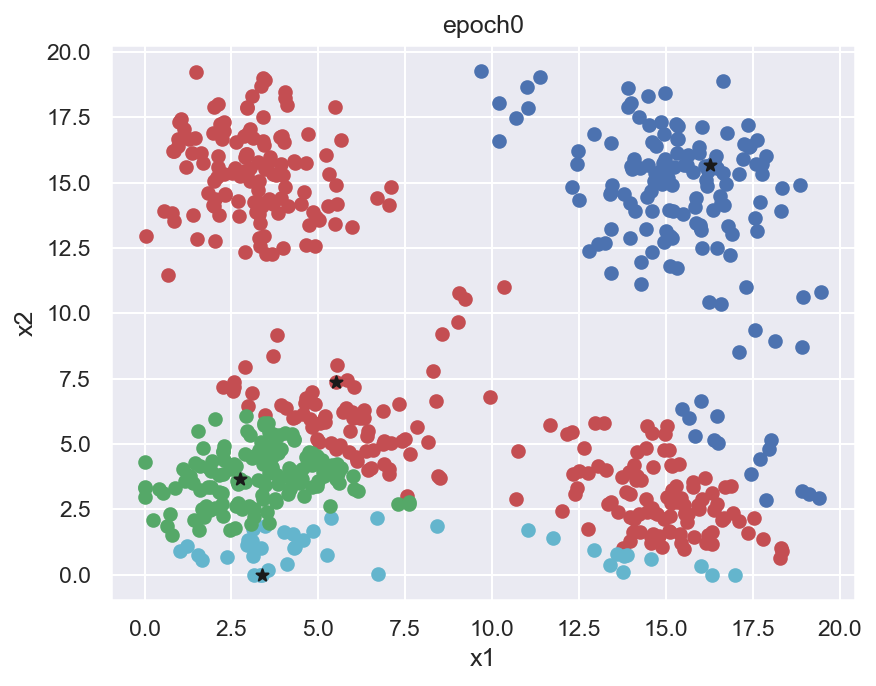

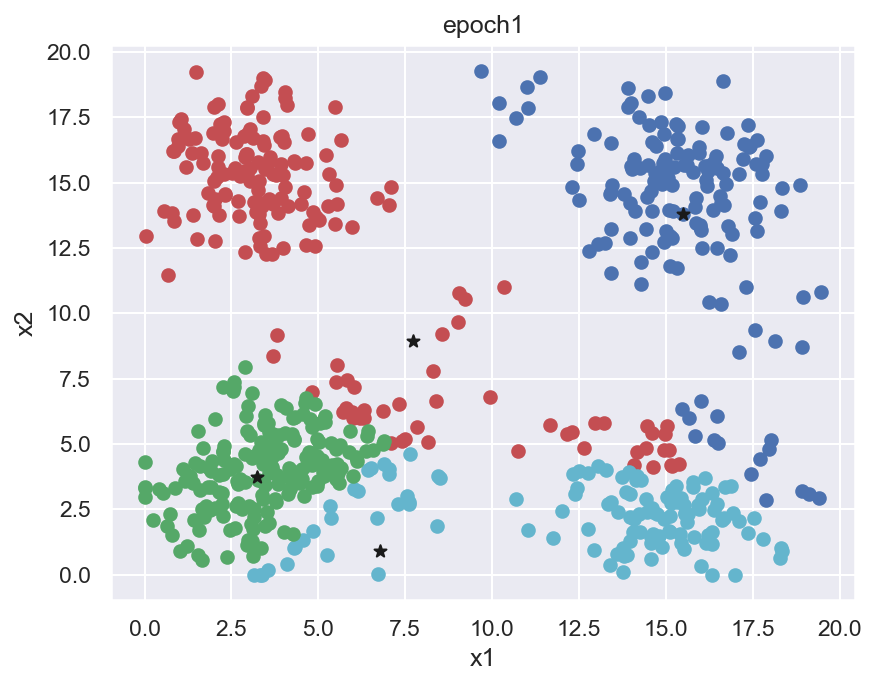

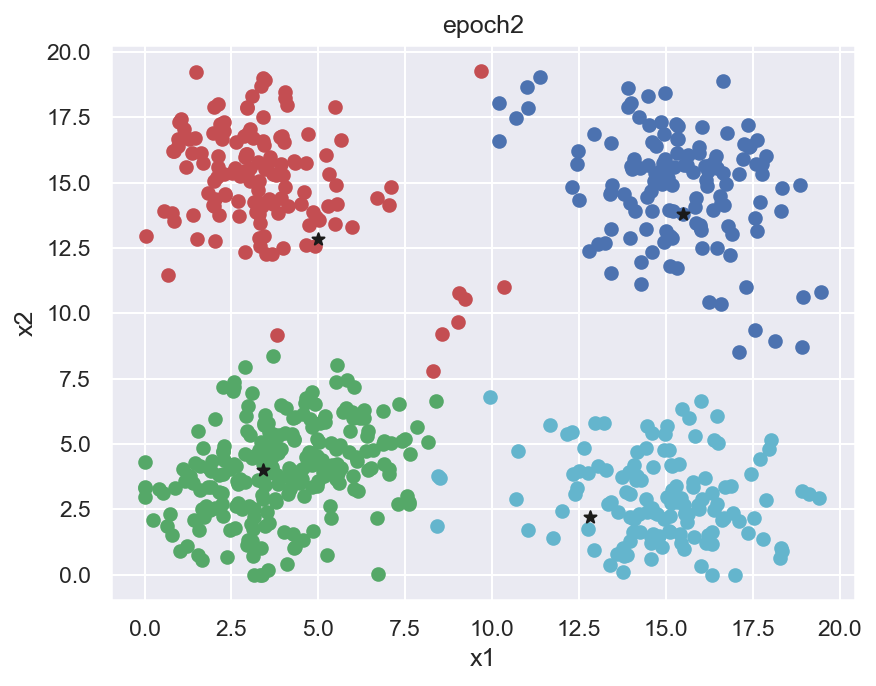

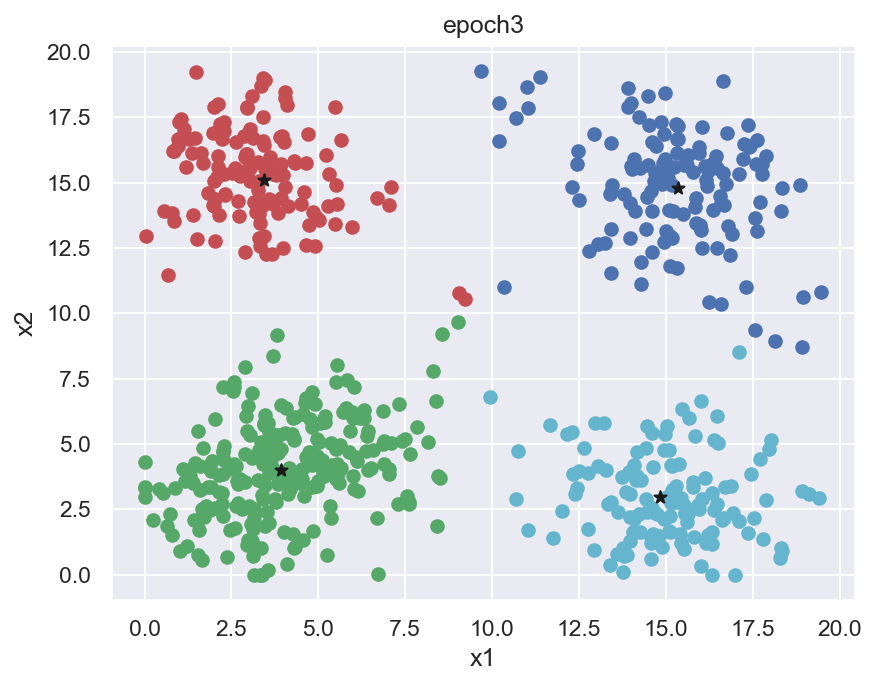

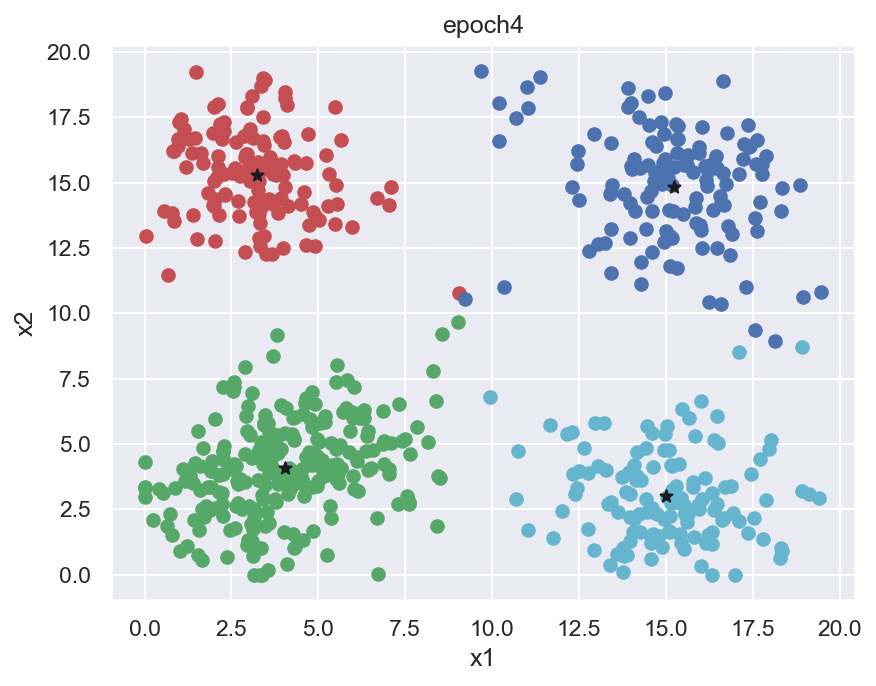

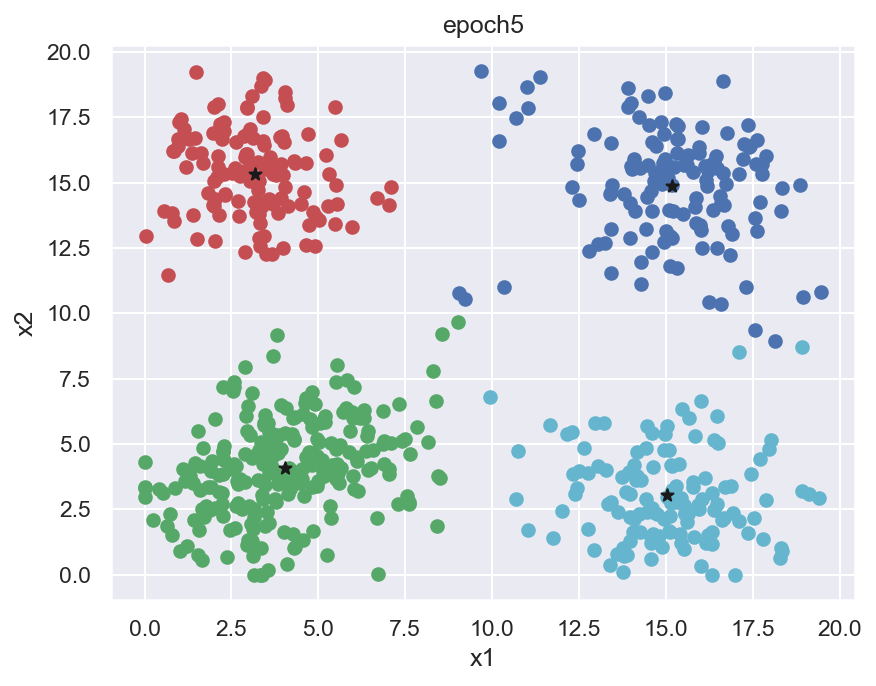

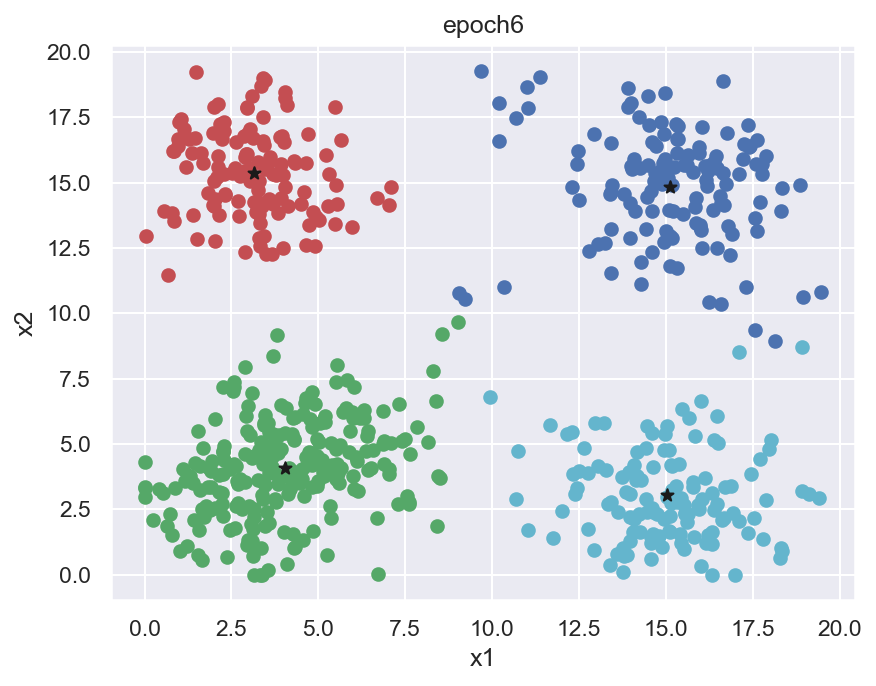

In [17]:
assignment, _ = kmeans(X, k, max_epoch)

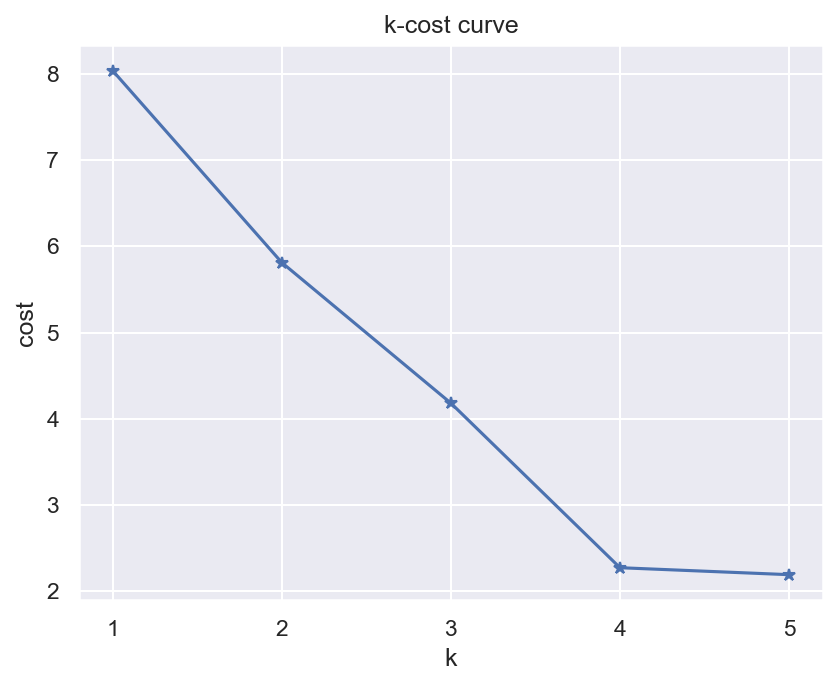

In [18]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
# 使用 cur_k 作为循环变量，避免覆盖前面已经选定的聚类簇数 k。
for cur_k in range(1, max_k):
    _, cost = kmeans(X, cur_k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()